## Trabajo Práctico 1 - Visión por Computadora

Integrantes:
- Matías Guillermo Alfaro
- Rodrigo Hernández
- Gonzalo Cuervo
- Nicolas Alberto Tonnelier
- Marina Andrea Racciatti

### Parte 1
1. Implementar el algoritmo White Patch para librarnos de las diferencias de color de iluminación.

### Algoritmo White Patch
El algoritmo White Patch es uno de los métodos más simples para intenta eliminar el efecto del color de la iluminación para que los colores de los objetos se parezcan más a los que tendrían bajo una luz blanca. Esto es necesario ya que el color que percibimos es el resultado de la luz que el objeto refleja, por lo que los objetos podrian mostrar colores distintos segun la diferencia de color de iluminación.

In [29]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import cv2 as cv

In [30]:
def white_patch(image, percentile=None):
    """
    Aplica el algoritmo White Patch.

    Parámetros
    ----------
    image : np.ndarray
        Imagen en formato RGB.
    percentile : float o None
        Si es None, usa el máximo absoluto.
        Si es un valor entre 0 y 100, usa ese percentil.

    Retorna
    -------
    np.ndarray
        Imagen corregida.
    """

    # Convertir a float para evitar overflow
    img = image.astype(np.float32)

    # Obtener referencia de cada canal
    if percentile is None:
        # White Patch clásico
        r_max = np.max(img[:, :, 0])
        g_max = np.max(img[:, :, 1])
        b_max = np.max(img[:, :, 2])
        print(f"Valores máximos: R={r_max}, G={g_max}, B={b_max}")

    else:
        # White Patch robusto
        r_max = np.percentile(img[:, :, 0], percentile)
        g_max = np.percentile(img[:, :, 1], percentile)
        b_max = np.percentile(img[:, :, 2], percentile)
        print(f"Valores máximos (percentil {percentile}): R={r_max}, G={g_max}, B={b_max}")
    
    # factor de corrección para cada canal
    r_factor = 255 / r_max if r_max != 0 else 1
    g_factor = 255 / g_max if g_max != 0 else 1
    b_factor = 255 / b_max if b_max != 0 else 1
    

    # Aplicar corrección
    img[:, :, 0] *= r_factor
    img[:, :, 1] *= g_factor
    img[:, :, 2] *= b_factor

    # Limitar al rango válido
    img = np.clip(img, 0, 255)

    return img.astype(np.uint8)

2. Mostrar resultados obtenidos y analizar posibles fallas

Valores máximos: R=165.0, G=138.0, B=200.0


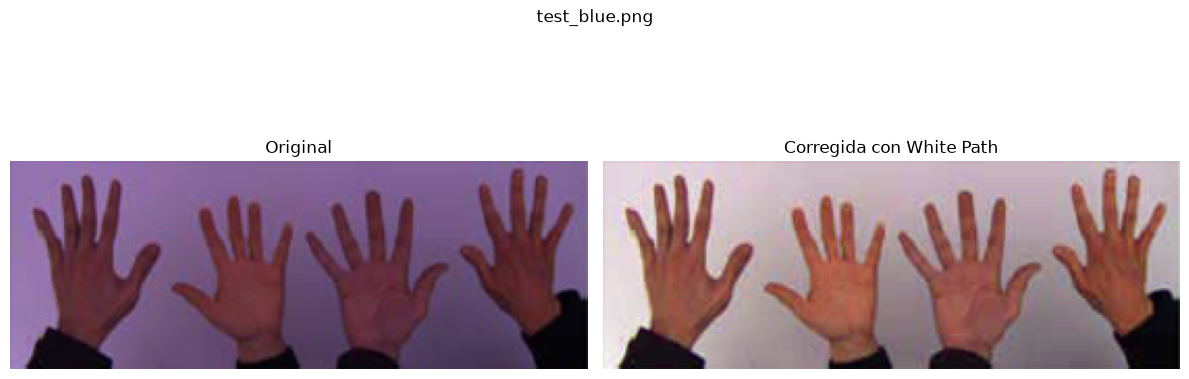

Valores máximos: R=210.0, G=250.0, B=171.0


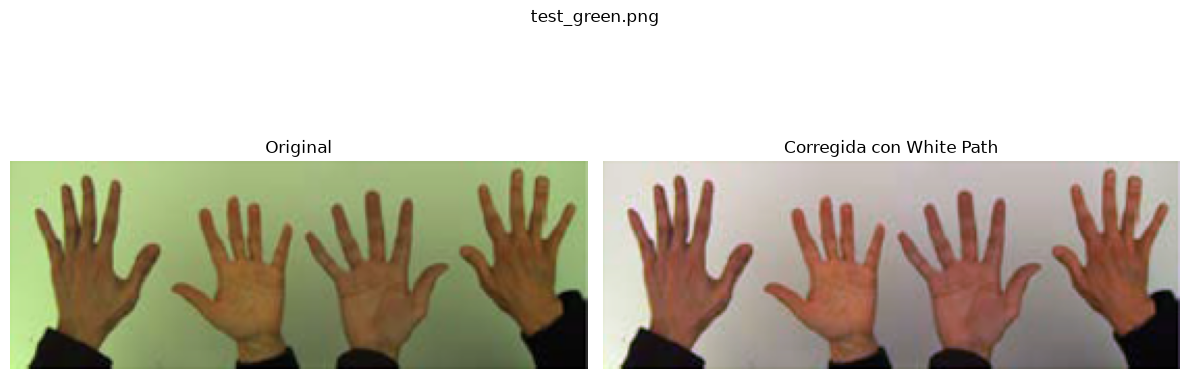

Valores máximos: R=247.0, G=157.0, B=175.0


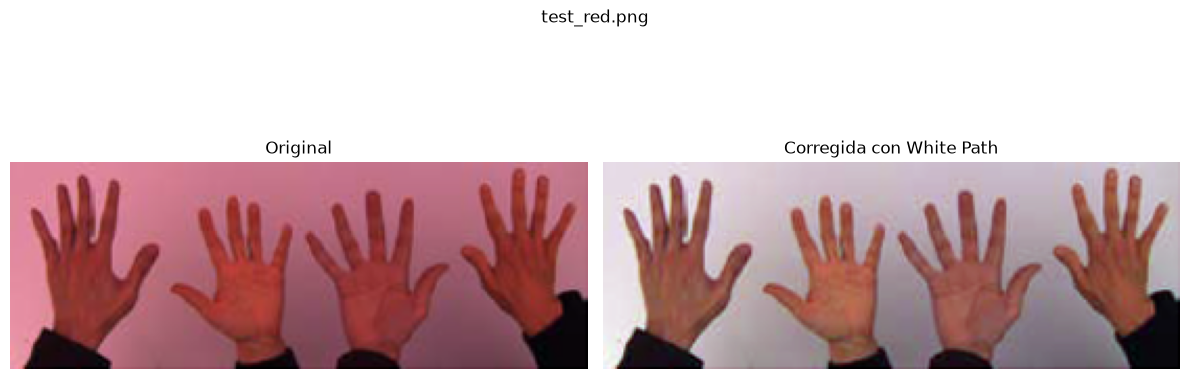

Valores máximos: R=255.0, G=255.0, B=255.0


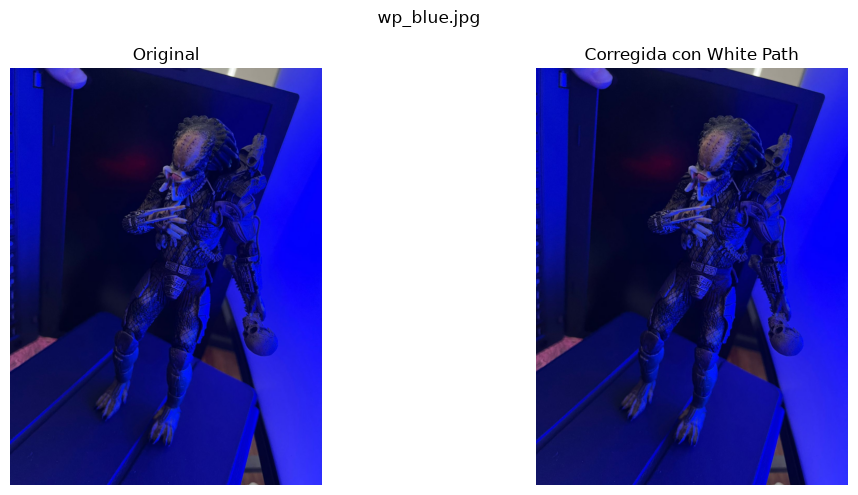

Valores máximos: R=126.0, G=252.0, B=155.0


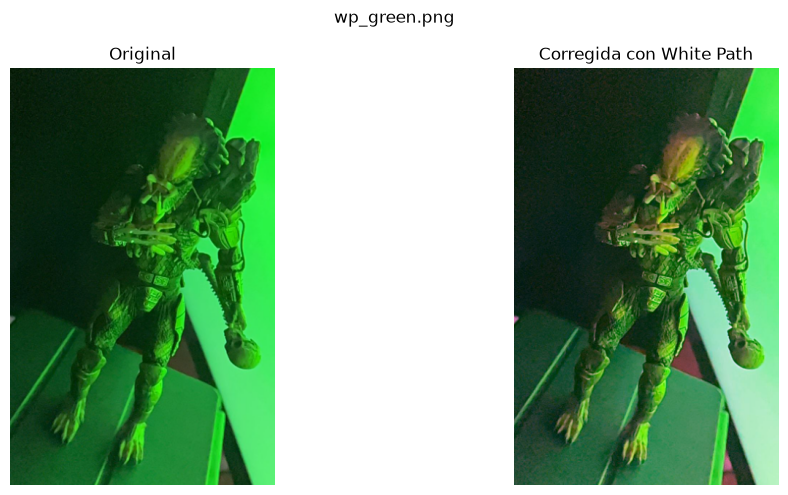

Valores máximos: R=170.0, G=255.0, B=172.0


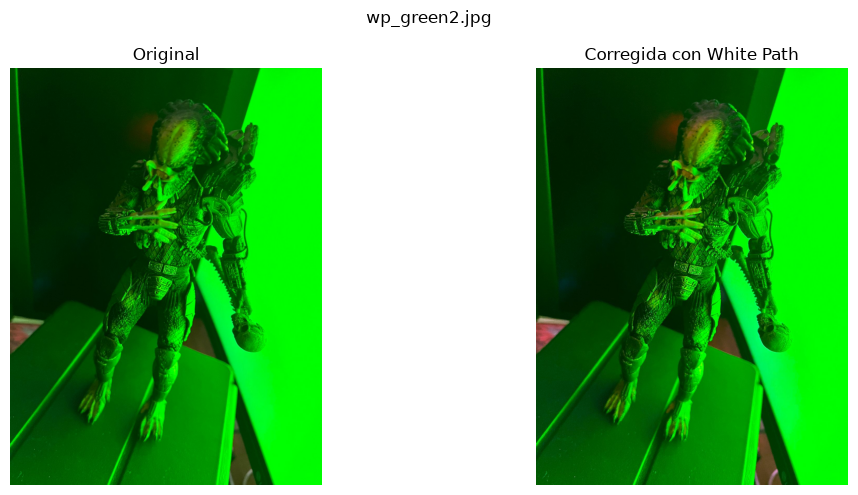

Valores máximos: R=255.0, G=134.0, B=122.0


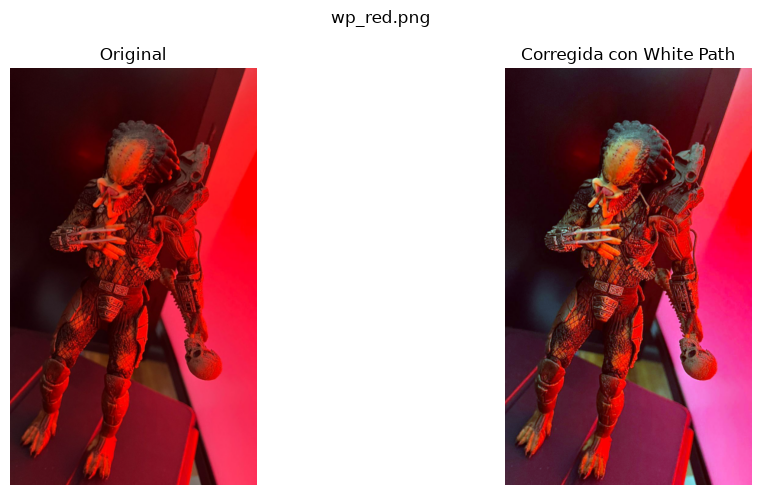

Valores máximos: R=255.0, G=201.0, B=203.0


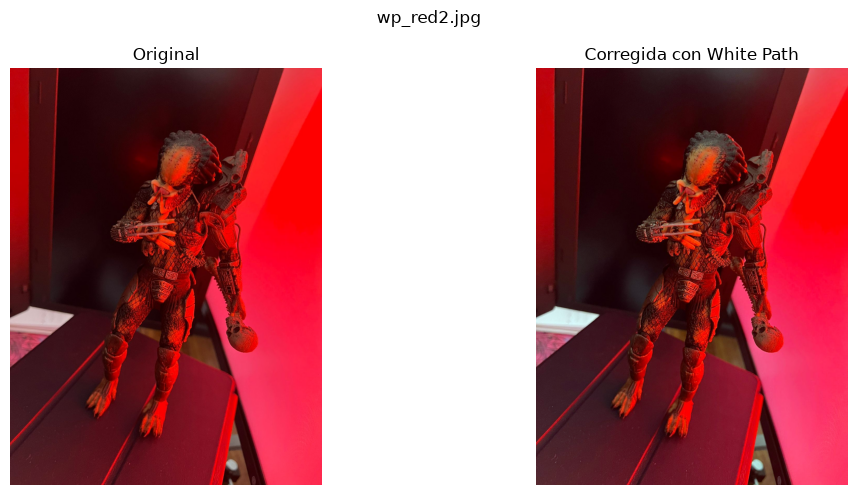

In [31]:
images_path = [ 'test_blue.png',
                'test_green.png',
                'test_red.png',
                'wp_blue.jpg',
                'wp_green.png',
                'wp_green2.jpg',
                'wp_red.png',
                'wp_red2.jpg' ]


for image_path in images_path:
    original_image = cv.imread('white_patch/' + image_path)
    original_image = cv.cvtColor(original_image, cv.COLOR_BGR2RGB)
    corrected_image = white_patch(original_image)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(original_image)
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(corrected_image)
    axes[1].set_title('Corregida con White Path')
    axes[1].axis('off')
    fig.suptitle(image_path)
    plt.tight_layout()
    plt.show()

Valores máximos: R=255.0, G=255.0, B=255.0
Valores máximos (percentil 99): R=117.0, G=86.0, B=254.0
Valores máximos (percentil 95): R=56.0, G=51.0, B=252.0


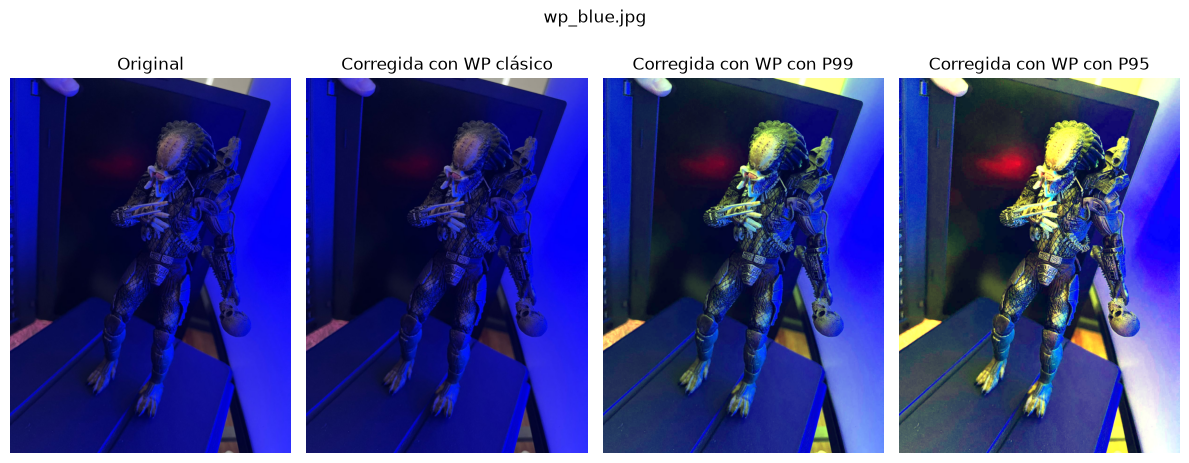

Valores máximos: R=126.0, G=252.0, B=155.0
Valores máximos (percentil 99): R=88.0, G=244.0, B=120.0
Valores máximos (percentil 95): R=80.0, G=237.0, B=113.0


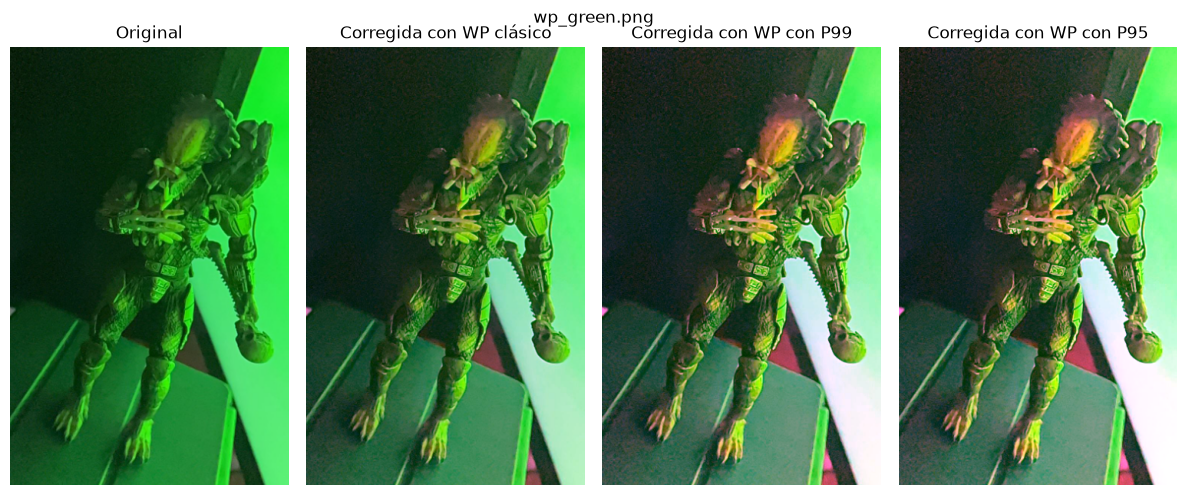

Valores máximos: R=170.0, G=255.0, B=172.0
Valores máximos (percentil 99): R=70.0, G=255.0, B=56.0
Valores máximos (percentil 95): R=30.0, G=255.0, B=24.0


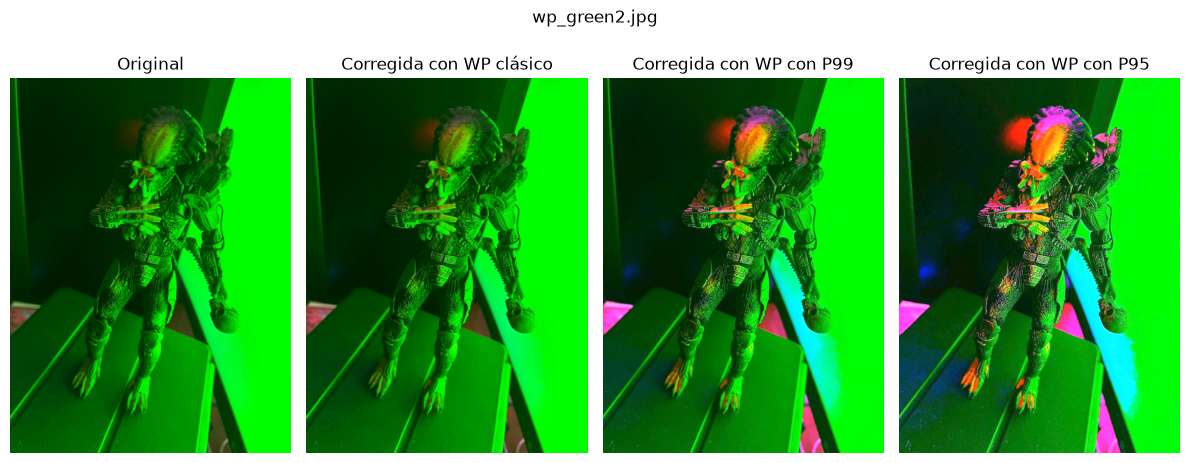

Valores máximos: R=255.0, G=134.0, B=122.0
Valores máximos (percentil 99): R=255.0, G=74.0, B=102.0
Valores máximos (percentil 95): R=255.0, G=58.0, B=90.0


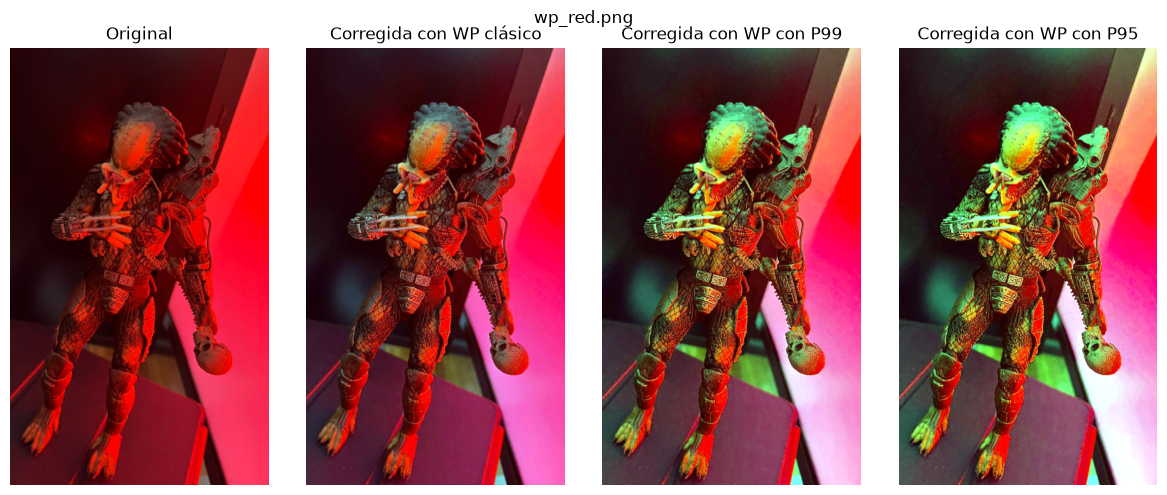

Valores máximos: R=255.0, G=201.0, B=203.0
Valores máximos (percentil 99): R=255.0, G=119.0, B=119.0
Valores máximos (percentil 95): R=255.0, G=60.0, B=90.0


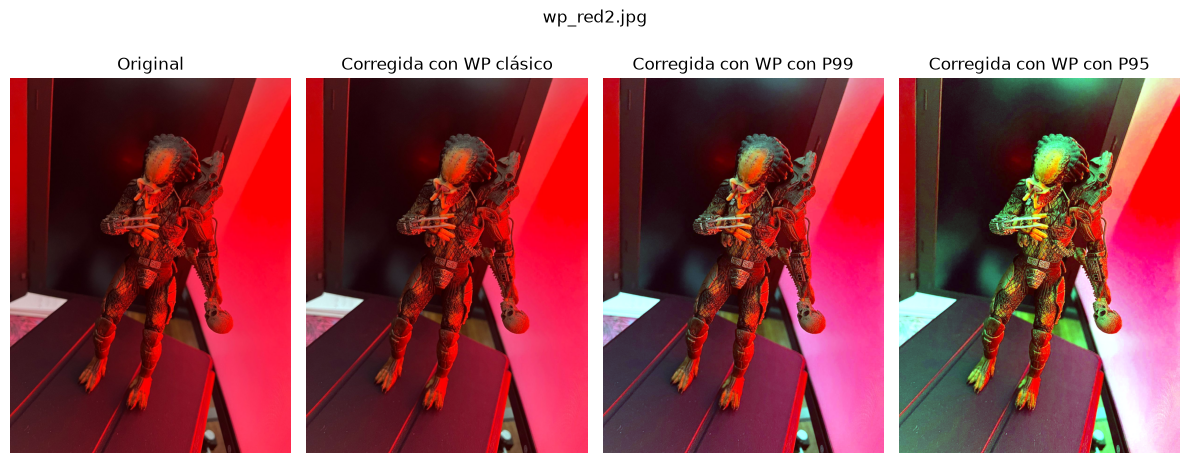

In [32]:
images_path2 = images_path[3:]


for image_path in images_path2:
    original_image = cv.imread('white_patch/' + image_path)
    original_image = cv.cvtColor(original_image, cv.COLOR_BGR2RGB)
    corrected_image = white_patch(original_image)
    corrected_image_p99 = white_patch(original_image, percentile=99)
    corrected_image_p95 = white_patch(original_image,percentile=95)

    fig, axes = plt.subplots(1, 4, figsize=(12, 5))
    axes[0].imshow(original_image)
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(corrected_image)
    axes[1].set_title('Corregida con WP clásico')
    axes[1].axis('off')
    axes[2].imshow(corrected_image_p99)
    axes[2].set_title('Corregida con WP con P99')
    axes[2].axis('off')
    axes[3].imshow(corrected_image_p95)
    axes[3].set_title('Corregida con WP con P95')
    axes[3].axis('off')
    fig.suptitle(image_path)
    plt.tight_layout()
    plt.show()

### Observaciones: 
- Al aplicar el algoritmo White Patch, las imagenes de las manos test_*.png quedan casi identicas, es decir, se logra quitar el efecto del color de iluminación. Sin embargo, no funciona White patch clasico para las imagenes de alien. A la vez, las imagenes de Alien .png empiezan a mostrar una limpieza en el color de la iluminación, sin llegar a ser todavia una limpieza completa, mientras que las .jpg apenas muestran cambios.
- Esto esta relacionado a los valores maximos y saturacion que hay en las imagenes. Las imagenes de las manos ninguna llega a valores maximos de 255 en su canal predominante. Y sin necesidad de un histograma, se puede ver que las imagenes .jpg de los alien tiene valores maximos mas altos en todos sus canales y saturacion en su color predominante(por ej red.jpg Valores máximos: R=255.0, G=201.0, B=203.0) que las imagenes de alien respectivas pero .png (red.png Valores máximos: R=255.0, G=134.0, B=122.0)
- Luego de aplica White patch con percentiles 99 y 95, concluimos que NO es posible mediante solo este algoritmo lograr quitar el efecto de iluminacion. Inclusive se puede ver como la imagen va empeorando debido a la perdida de informacion (wp_green2.jpg con p95). Los mejores resultados son los obtenidos en 'wp_green.png'y 'wp_red.png', con percentil 99.
- En general, el usar el percentil 95 pierde contraste y a la vez termina desbalanceando los colores y favoreciendo a alguno en algunas zonas. Por ejemplo: en wp_green2.jpg tenemos

        Valores máximos: R=170.0, G=255.0, B=172.0

        Valores máximos (percentil 99): R=70.0, G=255.0, B=56.0

        Valores máximos (percentil 95): R=30.0, G=255.0, B=24.0

    lo que significa que el factor de escala del rojo es 170/30 y del azul 172/24, aproximadamente 6 y 7 respectivamente. Creando en la imagen resultante lugares con predominancia de azul o rojo debido a que saturan.


### Parte 2

1. Para las imagenes `img1_tp.png` y `img2_tp.png`, leerlas con OpenCV en escala de grises y visualizarlas.
2. Elegir una cantidad de bins, graficar sus histogramas, compararlos y analizar si servirian como *features* para clasificacion/deteccion.

Uso 64 bins: agrupa cada 4 niveles de gris, reduce un poco el ruido frente a 256 bins y conserva suficiente detalle para comparar la distribucion de intensidades. Además, mejora la escala frente a la gran concentracion de pixeles en 255.

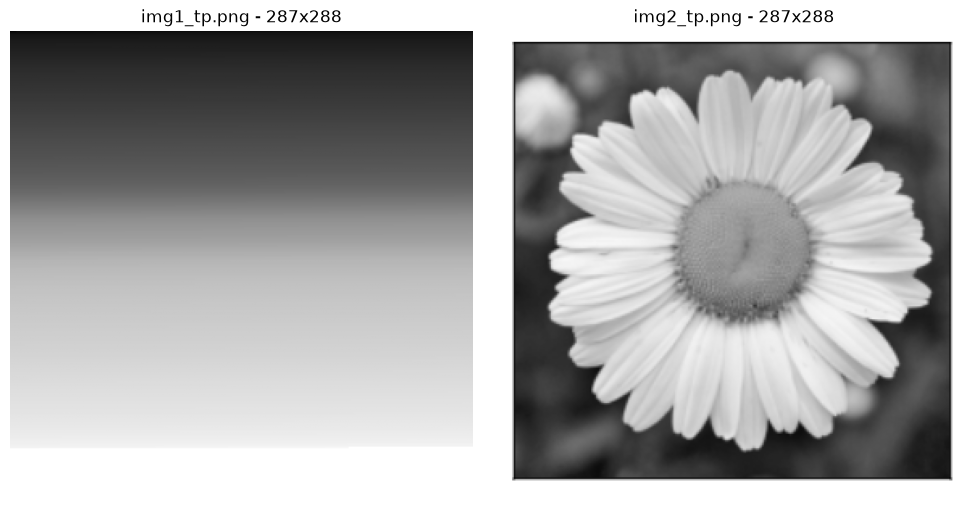

In [33]:
img1 = cv.imread('img1_tp.png', cv.IMREAD_GRAYSCALE)
img2 = cv.imread('img2_tp.png', cv.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    raise FileNotFoundError('No se pudieron cargar img1_tp.png e img2_tp.png')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, image, title in zip(axes, (img1, img2), ('img1_tp.png', 'img2_tp.png')):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{title} - {image.shape[1]}x{image.shape[0]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

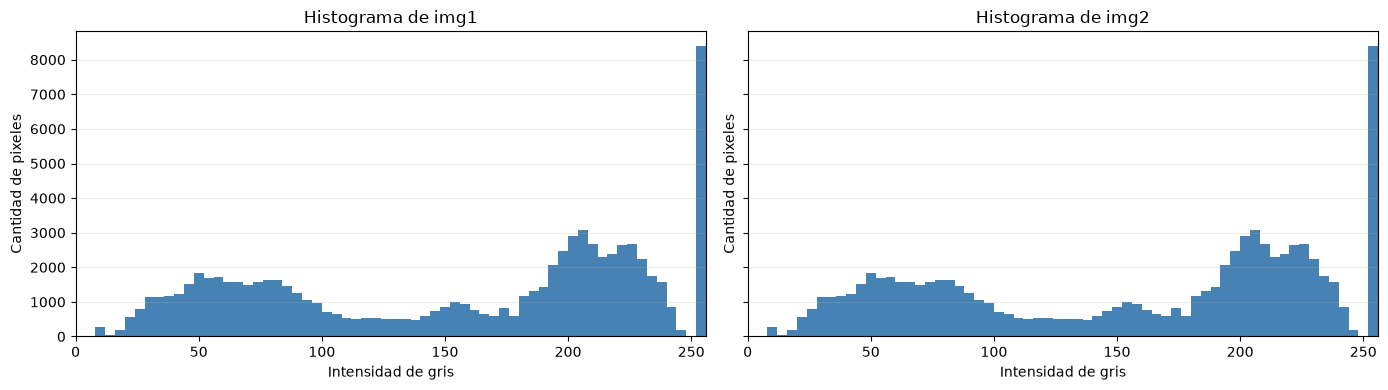

Las imagenes son identicas pixel a pixel? False
Los histogramas son identicos? True
img1: minimo=2, maximo=255, media=154.81, desvio=75.34
img2: minimo=2, maximo=255, media=154.81, desvio=75.34


In [34]:
bins = 64
hist1 = cv.calcHist([img1], [0], None, [bins], [0, 256]).ravel()
hist2 = cv.calcHist([img2], [0], None, [bins], [0, 256]).ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, hist, title in zip(axes, (hist1, hist2), ('Histograma de img1', 'Histograma de img2')):
    ax.bar(np.linspace(0, 252, bins), hist, width=4, align='edge', color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('Intensidad de gris')
    ax.set_xlim(0, 256)
    ax.set_ylabel('Cantidad de pixeles')
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

print(f'Las imagenes son identicas pixel a pixel? {np.array_equal(img1, img2)}')
print(f'Los histogramas son identicos? {np.array_equal(hist1, hist2)}')
for name, image in [('img1', img1), ('img2', img2)]:
    print(f'{name}: minimo={image.min()}, maximo={image.max()}, media={image.mean():.2f}, desvio={image.std():.2f}')

#### Análisis

Los histogramas son iguales, aunque las imágenes no son idénticas pixel a pixel. Por lo tanto, ambas tienen la misma cantidad de pixeles de cada intensidad, pero esos pixeles estan ubicados en posiciones distintas. Un histograma global descarta la informacion espacial: no describe formas, bordes, textura localizada ni la posicion de los objetos.

Como *feature*, un histograma puede ser util para tareas simples en las que el brillo, contraste o distribucion global de intensidades esten asociados a la clase; tambien puede complementar otras caracteristicas. Sin embargo, no seria suficiente por si solo para clasificacion o deteccion: en este ejemplo no logra distinguir las dos imagenes. Para deteccion es especialmente limitado porque no conserva localizacion. Conviene combinarlo con caracteristicas espaciales como HOG, LBP o descriptores locales, o usar representaciones aprendidas por una CNN, segun la tarea.
Un ejemplo, seria un modelo para predecir a partir de imagenes el estado de maduracion de una naranja. Al hacer histogramas de los canales RGB, podriamos encontrar patrones de intensidad de los colores que indiquen su estado: inmadura, madura o pasada.

Sin embargo, donde podria ser más importante el uso de histogramas es en el EDA y etapa de preparación de datos(imágenes), donde podria usarse para mejorar los datos con técnicas como ecualización.